<a href="https://colab.research.google.com/github/LeonimerMelo/Deep_Learning/blob/Perceptron/Simple_Perceptron_Implementation_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
# creating a dataset with linearly separable data --> perceptron hability
X, y = make_blobs(n_samples=200, n_features=2, centers=2, cluster_std=.7, shuffle=True, random_state=0)
X.shape

(200, 2)

In [2]:
X[0:2]

array([[2.59193175, 1.14706863],
       [1.7756532 , 1.15670278]])

In [3]:
sep=np.array([[-1,2.2], [4,3.2]])
sep

array([[-1. ,  2.2],
       [ 4. ,  3.2]])

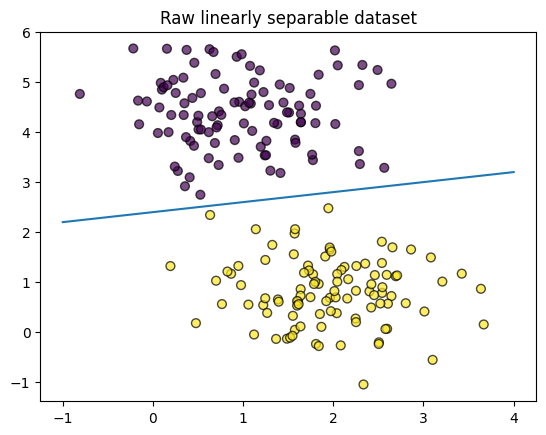

In [55]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, alpha=0.7, edgecolors='black')
plt.title("Raw linearly separable dataset")
# plt.plot([-1,4], [2.4,2.9])
plt.plot(sep[:, 0], sep[:, 1])
plt.show()

In [8]:
# standardization --> normalization
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X)
X_std = sc.transform(X)
X_std.shape

(200, 2)

In [9]:
sep_std = sc.transform(sep)
sep_std

array([[-2.89465022, -0.2089063 ],
       [ 2.99754093,  0.31432349]])

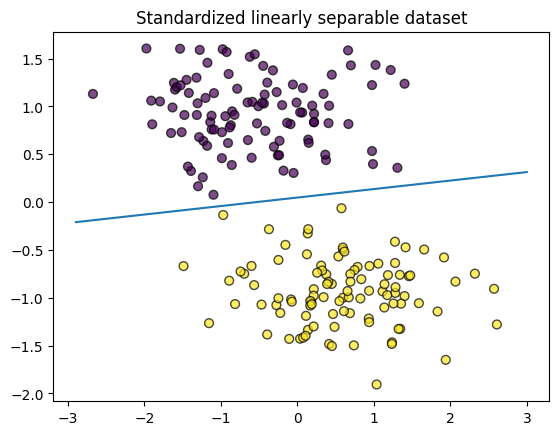

In [56]:
plt.scatter(X_std[:, 0], X_std[:, 1], c=y, s=40, alpha=0.7, edgecolors='black')
plt.title("Standardized linearly separable dataset")
plt.plot(sep_std[:, 0], sep_std[:, 1])
plt.show()

In [13]:
# original classes 10 samples
y[:10]

array([ 1,  1,  1,  1, -1, -1, -1, -1,  1, -1])

In [12]:
# 0 to -1 class change for better perceptron computation
y = np.where(y == 0, -1, 1)
y[:10]

array([ 1,  1,  1,  1, -1, -1, -1, -1,  1, -1])

## The perceptron learning rule

The whole idea behind the MCP neuron and Rosenblatt's *thresholded* perceptron model is to use a reductionist approach to mimic how a single neuron in the brain works: it either *fires* or it doesn't. Thus, Rosenblatt's initial perceptron rule is fairly simple and can be summarized by the following steps:

1. Initialize the weights to 0 or small random numbers.
2. For each training sample $x^{(i)}$:

  a) Compute the output value $\hat{y}$.
  $$ \hat{y}(z^{(i)})=\left\{\begin{matrix}
1 \;\mathrm{if} \;z^{(i)} \geqslant 0 \\
-1 \; \mathrm{otherwise}
\end{matrix}\right.$$

  b) Update the weights.

Here, the output value is the class label predicted by the unit step function that we defined earlier, and the simultaneous update of each weight $w_j$ in the weight vector $\mathbf{w}$ can be more formally written as:

$$ w_j:=w_j+\Delta w_j$$

The value of $\Delta w_j$, which is used to update the weight
$w_j$, is calculated by the perceptron learning rule:

$$\Delta w_j=\eta \left ( y^{(i)}-\hat{y}^{(i)} \right ) x_j^{(i)}$$

Where $\eta$ is the **learning rate** (typically a constant between 0.0 and 1.0), $y^{(i)}$ is the
**true class label** of the ith training sample, and $\hat{y}^{(i)}$ is the **predicted class label** and $x_j^{(i)}$ is the training sample.


In [14]:
# adiciona uma coluna de '1' correspondente ao bias --> weight(0)
X_ones = np.c_[np.ones(X_std.shape[0]), X_std]
print('X shape:', X_std.shape)
print('X_ones shape:', X_ones.shape)

# Initialize the weights to 1
w = np.ones(X_ones.shape[1])
print('initial weights w =', w)

X shape: (200, 2)
X_ones shape: (200, 3)
initial weights w = [1. 1. 1.]


In [15]:
# learning rate
eta = 0.01
# number of iterations (epochs)
n_epochs = 100
# errors vector per epochs
errors_ = []

# Initialize the weights to 1
w = np.ones(X_ones.shape[1])
# Initialize the weights to 0
# w = np.zeros(X_ones.shape[1])
# Initialize the weights to 0.5
# w = np.array([.5, .5, .5])

# soma quantas vezes atingiu erro zero
errosZero = 0
for i in range(n_epochs):
    errors = 0
    for j in range(len(X_ones)):
        xi = X_ones[j]
        yi = y[j]
        # z = net input function = somatório(w.X)
        z = np.dot(w, xi)
        # Compute the prediction output value y (y_hat)
        y_hat = np.where(z >= 0.0, 1, -1)
        # calculate delta weight
        delta_W = eta * (yi - y_hat) * xi
        # Update the weights
        w += delta_W
        # se a previsão (y_hat) != label (y) --> + 1 no erro
        if yi != y_hat:
            errors += 1

    print(f"éporca: {i+1}  pesos: {w.round(2)}  erros: {errors}")
    # armazeno a quantidade de erros de cada época
    errors_.append(errors)

    if errors == 0:
      errosZero +=1
      if errosZero > 2:
        print('Parada no treinamento! Erro zero!')
        break

# o objetivo final é calcular os pesos (weights) das entradas através do treinamento da rede
print('\nOs pesos da rede treinada:', w)

éporca: 1  pesos: [ 0.18  0.88 -0.3 ]  erros: 69
éporca: 2  pesos: [ 0.04  0.58 -0.6 ]  erros: 17
éporca: 3  pesos: [-0.    0.43 -0.67]  erros: 6
éporca: 4  pesos: [-0.02  0.32 -0.71]  erros: 5
éporca: 5  pesos: [-0.    0.24 -0.73]  erros: 3
éporca: 6  pesos: [-0.    0.2  -0.74]  erros: 2
éporca: 7  pesos: [ 0.02  0.18 -0.75]  erros: 1
éporca: 8  pesos: [ 0.04  0.16 -0.75]  erros: 1
éporca: 9  pesos: [ 0.06  0.14 -0.75]  erros: 1
éporca: 10  pesos: [ 0.06  0.14 -0.75]  erros: 0
éporca: 11  pesos: [ 0.06  0.14 -0.75]  erros: 0
éporca: 12  pesos: [ 0.06  0.14 -0.75]  erros: 0
Parada no treinamento! Erro zero!

Os pesos da rede treinada: [ 0.06        0.14008977 -0.75113176]


####Vamos entender o funcionamento do perceptron passo a passo

In [ ]:
# adiciona uma coluna de '1' correspondente ao bias --> weight(0)
X_ones = np.c_[np.ones(X_std.shape[0]), X_std]
print('X_std shape:', X_std.shape)
print('X_ones shape:', X_ones.shape)

X_std shape: (200, 2)
X_ones shape: (200, 3)


In [ ]:
# cinco primeras amostras do banco de dados normalizados
X_std[:5]

array([[ 1.33821947, -0.75983136],
       [ 0.37628563, -0.75479049],
       [ 1.58721446, -1.05638495],
       [ 0.17996772, -1.03583259],
       [ 0.69866193,  1.4300265 ]])

In [ ]:
# cinco primeras amostras do banco de dados + peso zero w[0]
X_ones[:5]

array([[ 1.        ,  1.33821947, -0.75983136],
       [ 1.        ,  0.37628563, -0.75479049],
       [ 1.        ,  1.58721446, -1.05638495],
       [ 1.        ,  0.17996772, -1.03583259],
       [ 1.        ,  0.69866193,  1.4300265 ]])

In [ ]:
# learning rate
eta = 0.01
# number of iterations (epochs)
n_epochs = 25
# errors vector per epochs
errors_ = []
# Initialize the weights to 1
w = np.ones(X_ones.shape[1])
print('pesos iniciais:', w)
# soma quantas vezes atingiu erro zero
errosZero = 0

pesos iniciais: [1. 1. 1.]


Loop for começa aqui!

In [ ]:
# loop for percorrendo cada amostra do banco de dados com o rótulo equivalente
# for j in range(len(X_ones)):
# vamos pegar a primeira amostra como exemplo
j=0
# j=30

In [ ]:
xi = X_ones[j]
yi = y[j]
print('amostra:', xi, 'rótulo:', yi)

amostra: [ 1.         -1.53345543  1.60373025] rótulo: -1


In [ ]:
# z = net input function = somatório(w.X)
z = np.dot(w, xi)
z

np.float64(1.0702748207436286)

In [ ]:
# Compute the prediction output value y (y_hat)
y_hat = np.where(z >= 0.0, 1, -1)
y_hat

array(1)

$\Delta w_j=\eta \left ( y^{(i)}-\hat{y}^{(i)} \right ) x_j^{(i)}$

In [ ]:
# calculate delta weight
delta_W = eta * (yi - y_hat) * xi
delta_W

array([-0.02      ,  0.03066911, -0.03207461])

$ w_j:=w_j+\Delta w_j$

In [ ]:
# Update the weights
w += delta_W
w

array([0.98      , 1.03066911, 0.96792539])

Retorna ao loop for até o final do dataset

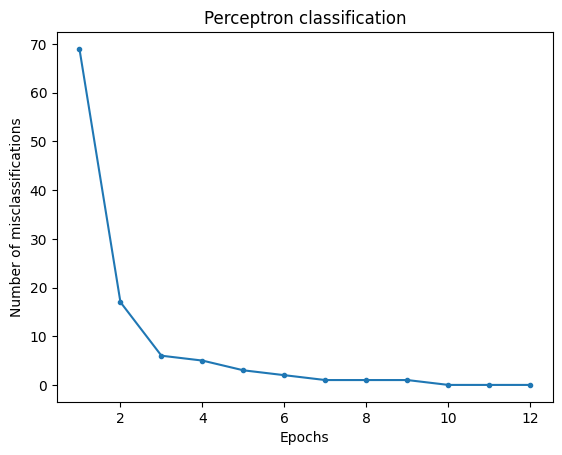

In [16]:
# plot do gráfico dos erros ao longo do treinamento
plt.plot(range(1, len(errors_) + 1), errors_, marker='.')
plt.xlabel('Epochs')
plt.ylabel('Number of misclassifications')
plt.title('Perceptron classification')
plt.show()

In [51]:
new_d =  np.array([[1,2], [1,3], [0,1.5], [0,3]])
new_d

array([[1. , 2. ],
       [1. , 3. ],
       [0. , 1.5],
       [0. , 3. ]])

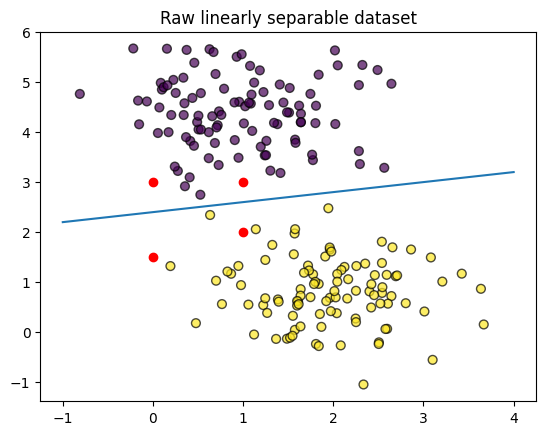

In [52]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, alpha=0.7, edgecolors='black')
plt.title("Raw linearly separable dataset")
plt.plot(sep[:, 0], sep[:, 1])
plt.plot(new_d[:,0], new_d[:,1], 'ro')
plt.show()

###Prediction
For predictions, simply use the perceptron with the weights already trained and compute the output value y_hat.
<center><img src='https://drive.google.com/uc?id=1idZn-XU0rfw9qpEzPd2sK0VhiVDUg_Ob' width=400></center>

In [57]:
def prediction(X, w_=w):
  new_d_std = sc.transform(X)
  X_new = np.c_[np.ones(new_d_std.shape[0]), new_d_std]
  for j in range(len(X_new)):
      z = np.dot(w_, X_new[j])
      y_hat = np.where(z >= 0.0, 1, -1)
      print('Raw data:', new_d[j], ' Class prediction:', y_hat)


In [58]:
prediction(new_d)

Raw data: [1. 2.]  Class prediction: 1
Raw data: [1. 3.]  Class prediction: -1
Raw data: [0.  1.5]  Class prediction: 1
Raw data: [0. 3.]  Class prediction: -1
